In [ ]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

In [ ]:
# Plotting the PDF

def plot_beta(a, b, size=1000):
    x = np.linspace(0, 1, size)
    y = beta.pdf(x, a, b)
    plt.plot(x, y, label=f'Beta({a:.2f}, {b:.2f})')
    
    # Mark the 95% CI
    lower_bound = beta.ppf(0.025, a, b)
    upper_bound = beta.ppf(0.975, a, b)
    mean = beta.ppf(0.5, a, b)
    plt.axvline(mean, color='black', linestyle='--', label=f'Mean ({mean:.2f})')
    
    plt.axvline(lower_bound, color='grey', linestyle='--', label=f'Lower ({lower_bound:0.2f})')
    plt.axvline(upper_bound, color='grey', linestyle='--', label=f'Upper ({upper_bound:0.2f})')
    
    # Labels and legend
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.title('Best-Fit Beta Distribution with 95% CI')
    plt.legend()

Best a: 8.0, Best b: 61.0, Error: 5.2113622982273665e-06


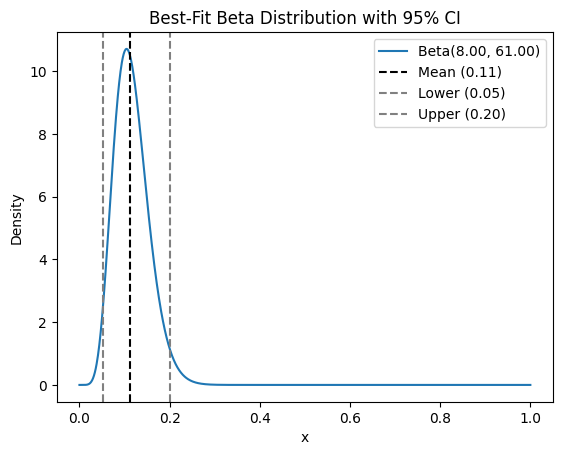

In [40]:
# Initialize variables
best_a, best_b = None, None
best_error = float('inf')

N = 100
errors = np.zeros(shape=(N, N))
a_vector = np.linspace(1, 100, N)
b_vector = np.linspace(1, 100, N)

# Grid search on a and b
for i, a in enumerate(a_vector):
    for j, b in enumerate(b_vector):
        
        # Calculate the 2.5% and 97.5% quantiles
        lower_bound = beta.ppf(0.025, a, b)
        upper_bound = beta.ppf(0.975, a, b)
        
        # Calculate error as (lower_bound - 0.05)^2 + (upper_bound - 0.2)^2
        error = (lower_bound - 0.05)**2 + (upper_bound - 0.2)**2
        errors[i][j] = error
        
        # Update best parameters if this error is lower
        if error < best_error:
            best_error = error
            best_a, best_b = a, b

print(f"Best a: {best_a}, Best b: {best_b}, Error: {best_error}")
plot_beta(best_a, best_b)

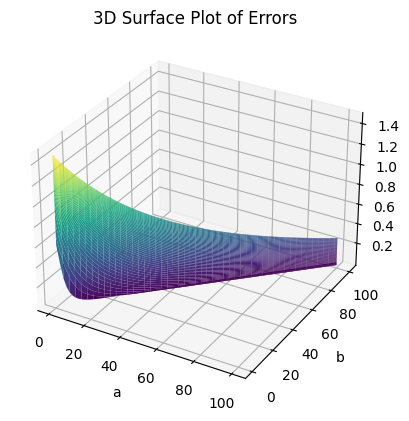

In [41]:

# # Sample 2D array 'errors' (replace this with your actual 2D array)
# x = np.linspace(0, 10, 100)
# y = np.linspace(0, 10, 100)
# X, Y = np.meshgrid(x, y)
# errors = np.sin(np.sqrt(X**2 + Y**2))

def plot_surface(x, y, errors):

    # Create the 3D surface plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    ax.plot_surface(x, y, errors, cmap='viridis')
    
    # Labels and title
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('Error')
    ax.set_title('3D Surface Plot of Errors')

plot_surface(a_vector, b_vector, errors)

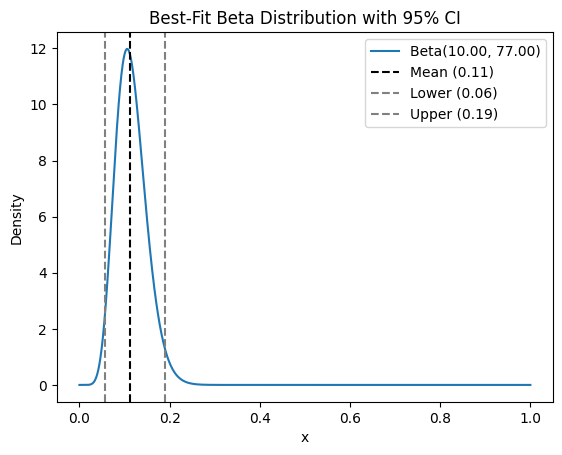

In [42]:
plot_beta(10, 77)

In [43]:
def map(a, b):
    return (a-1)/(a+b-2)

Optimal a: 0.1, Optimal b: 4.812153087302217


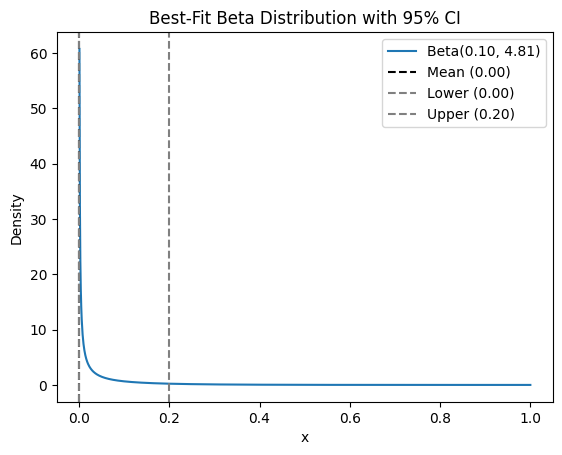

In [56]:
from scipy.optimize import minimize

# Define the objective function to minimize
def objective(params):
    a, b = params
    quantile1_diff = (beta.ppf(0.025, a, b) - 0.05)**2
    quantile2_diff = (beta.ppf(0.975, a, b) - 0.2)**2
    return quantile1_diff + quantile2_diff

# Initial guess
initial_guess = [1, 1]

# Run the optimizer
result = minimize(objective, initial_guess, bounds=[(0.1, 100), (0.1, 100)])

# Extract the optimal parameters
optimal_a, optimal_b = result.x
print(f"Optimal a: {optimal_a}, Optimal b: {optimal_b}")
plot_beta(optimal_a, optimal_b)

In [55]:
result

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 0.0025000108523569055
        x: [ 1.000e-01  4.812e+00]
      nit: 7
      jac: [ 2.517e-04 -8.462e-06]
     nfev: 30
     njev: 10
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>